<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Comparative Analysis of Machine Learning Classifiers and Ensemble Methods for Breast Cancer Diagnosis Using an Enhanced Feature Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ─── Install Dependencies ───
!pip install -q xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn

# ─── Imports ───
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})
SEED = 42
np.random.seed(SEED)

print("Environment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
Environment ready.


In [4]:
# ─── Load Dataset ───
df = pd.read_csv("/content/drive/MyDrive/Dataset/breast_cancer_enhanced_dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['diagnosis'].value_counts()}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Drop id and prepare target
df = df.drop(columns=['id'])
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # B=0, M=1

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"Features: {X.shape[1]}")
df.head()

Dataset shape: (5500, 17)
Class distribution:
diagnosis
B    3470
M    2030
Name: count, dtype: int64
Missing values: 0
Features: 15


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
0,0,11.829858,21.726166,75.154378,435.022394,0.087089,0.050717,0.015868,0.011641,0.078226,0.000185,0.026075,257.017451,0.187718,0.000036,22.433798
1,0,10.991150,17.103260,71.798929,381.386295,0.089339,0.109498,0.097344,0.035629,0.242470,0.003468,0.080823,187.984489,1.069921,0.000255,24.021839
2,1,21.433519,15.092437,142.753006,1392.399890,0.099557,0.152079,0.193372,0.126922,0.472373,0.024543,0.157458,323.484034,4.144647,0.000139,49.053992
3,0,11.700452,14.872127,74.154481,404.112556,0.101291,0.077563,0.043749,0.028747,0.150059,0.001258,0.050020,174.010599,0.511885,0.000108,23.276145
4,0,13.259377,17.212990,83.621014,521.124238,0.072905,0.043312,0.046983,0.010096,0.100391,0.000474,0.033464,228.233523,0.622960,0.000090,25.647074


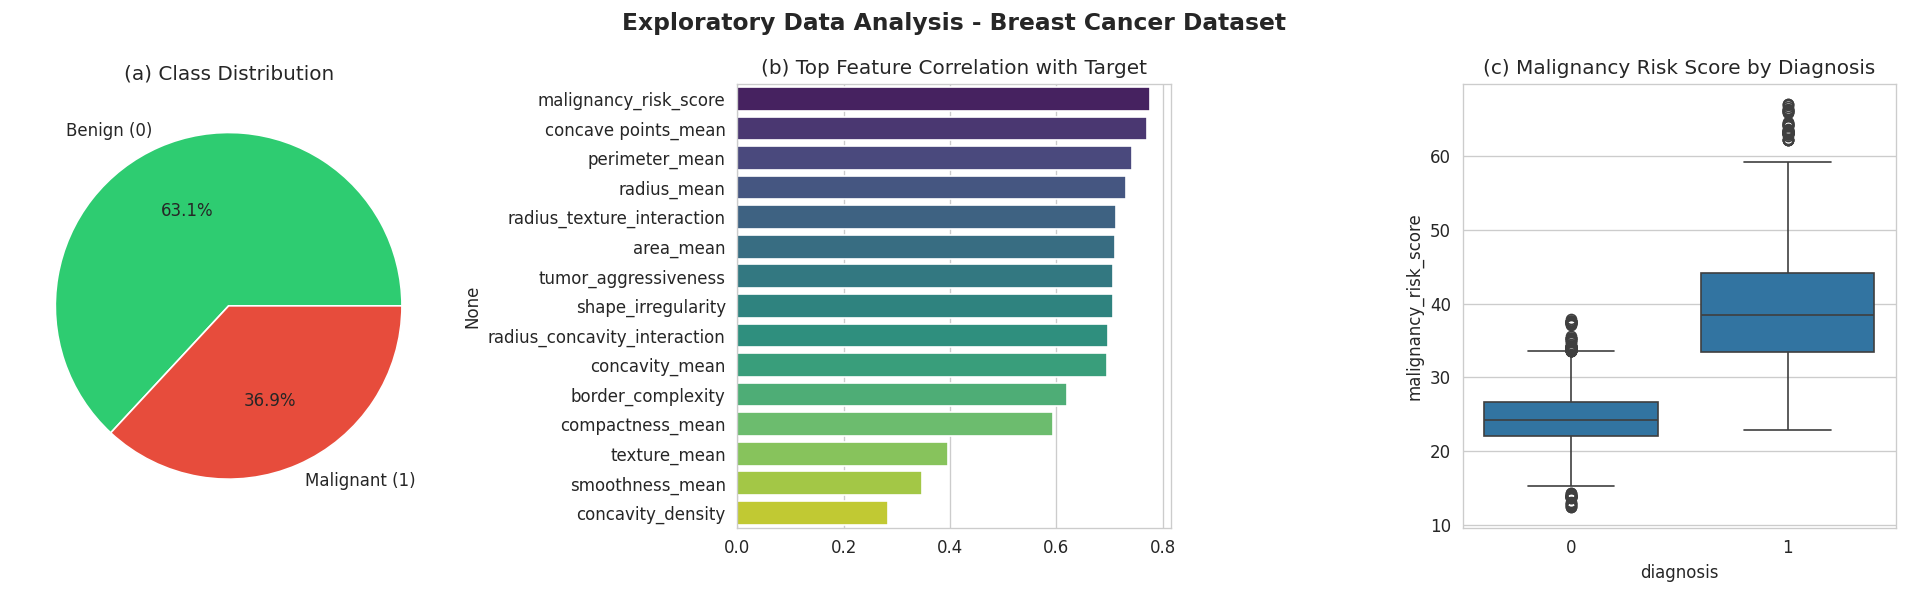

In [5]:
# ─── EDA ───
num_df = X.copy()
num_df['diagnosis'] = y

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class Distribution
lbl = y.value_counts()
axes[0].pie(lbl, labels=['Benign (0)', 'Malignant (1)'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'])
axes[0].set_title("(a) Class Distribution")

# Correlation (top features)
corr = num_df.corr()['diagnosis'].abs().sort_values(ascending=False)
top_corr = corr[1:16]  # top 15 features
sns.barplot(x=top_corr.values, y=top_corr.index, ax=axes[1], palette="viridis")
axes[1].set_title("(b) Top Feature Correlation with Target")

# Feature distributions example
sns.boxplot(x='diagnosis', y='malignancy_risk_score', data=num_df, ax=axes[2])
axes[2].set_title("(c) Malignancy Risk Score by Diagnosis")

plt.suptitle("Exploratory Data Analysis - Breast Cancer Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




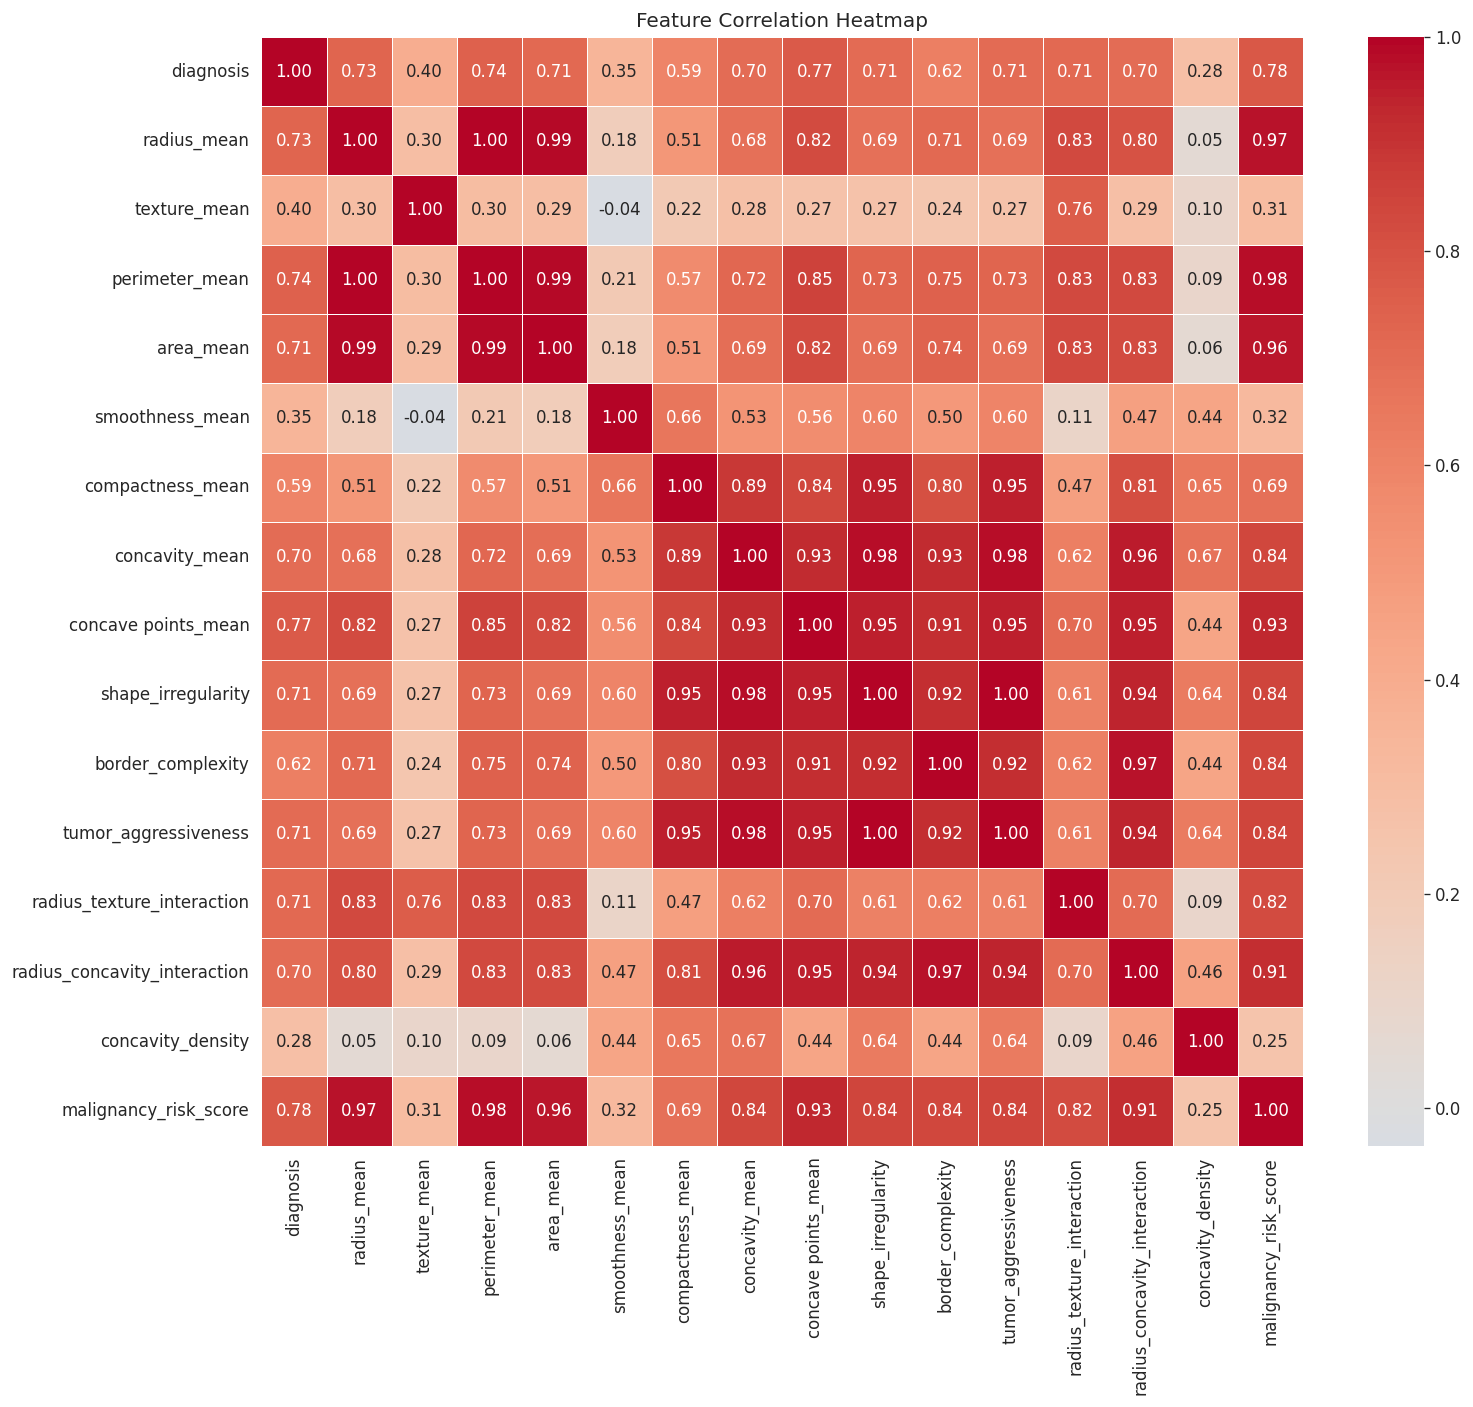

In [6]:
# Correlation Heatmap
plt.figure(figsize=(14, 12))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

# 2. Initialize the scaler
scaler = StandardScaler()

# 3. Fit ONLY on the training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [19]:
# ====================== MODELS ======================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', C=10, gamma="scale", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=SEED),
    "XGBoost": xgb.XGBClassifier(n_estimators=400, random_state=42, eval_metric='mlogloss'),
    "LightGBM": lgb.LGBMClassifier(n_estimators=400, random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(iterations=400, verbose=0, random_state=SEED)
}

results = []

print("Training Individual Classifiers...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

# ====================== VOTING ENSEMBLE ======================
print("Training Voting Ensemble (Soft)...\n")
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft'
)
voting_clf.fit(X_train, y_train)
y_pred_vot = voting_clf.predict(X_test)
y_prob_vot = voting_clf.predict_proba(X_test)[:, 1]

results.append({
    "Model": "Voting Ensemble (Soft)",
    "Accuracy": accuracy_score(y_test, y_pred_vot),
    "Precision": precision_score(y_test, y_pred_vot),
    "Recall": recall_score(y_test, y_pred_vot),
    "F1-Score": f1_score(y_test, y_pred_vot),
    "AUC-ROC": roc_auc_score(y_test, y_prob_vot)
})

# ====================== FINAL RESULTS ======================
results_df = pd.DataFrame(results).sort_values(by="Precision", ascending=False).round(4)
print("=== FINAL PERFORMANCE COMPARISON (Individual + Ensemble) ===")
print(results_df)

Training Individual Classifiers...

Training Voting Ensemble (Soft)...

=== FINAL PERFORMANCE COMPARISON (Individual + Ensemble) ===
                    Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
6                CatBoost    0.9991     1.0000  0.9975    0.9988   1.0000
5                LightGBM    0.9973     1.0000  0.9926    0.9963   1.0000
4                 XGBoost    0.9973     0.9975  0.9951    0.9963   0.9999
7  Voting Ensemble (Soft)    0.9936     0.9975  0.9852    0.9913   0.9998
3           Random Forest    0.9936     0.9950  0.9877    0.9913   1.0000
1                     KNN    0.9600     0.9714  0.9187    0.9443   0.9829
0     Logistic Regression    0.9300     0.9165  0.8916    0.9039   0.9814
2                     SVM    0.8918     0.8975  0.7980    0.8449   0.9664



DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES

🔹 Logistic Regression
------------------------------------------------------------
               precision    recall  f1-score   support

   Benign (B)     0.9376    0.9524    0.9450       694
Malignant (M)     0.9165    0.8916    0.9039       406

     accuracy                         0.9300      1100
    macro avg     0.9270    0.9220    0.9244      1100
 weighted avg     0.9298    0.9300    0.9298      1100


🔹 KNN
------------------------------------------------------------
               precision    recall  f1-score   support

   Benign (B)     0.9539    0.9841    0.9688       694
Malignant (M)     0.9714    0.9187    0.9443       406

     accuracy                         0.9600      1100
    macro avg     0.9626    0.9514    0.9565      1100
 weighted avg     0.9603    0.9600    0.9598      1100


🔹 SVM
------------------------------------------------------------
               precision    recall  f1-score   support

   B

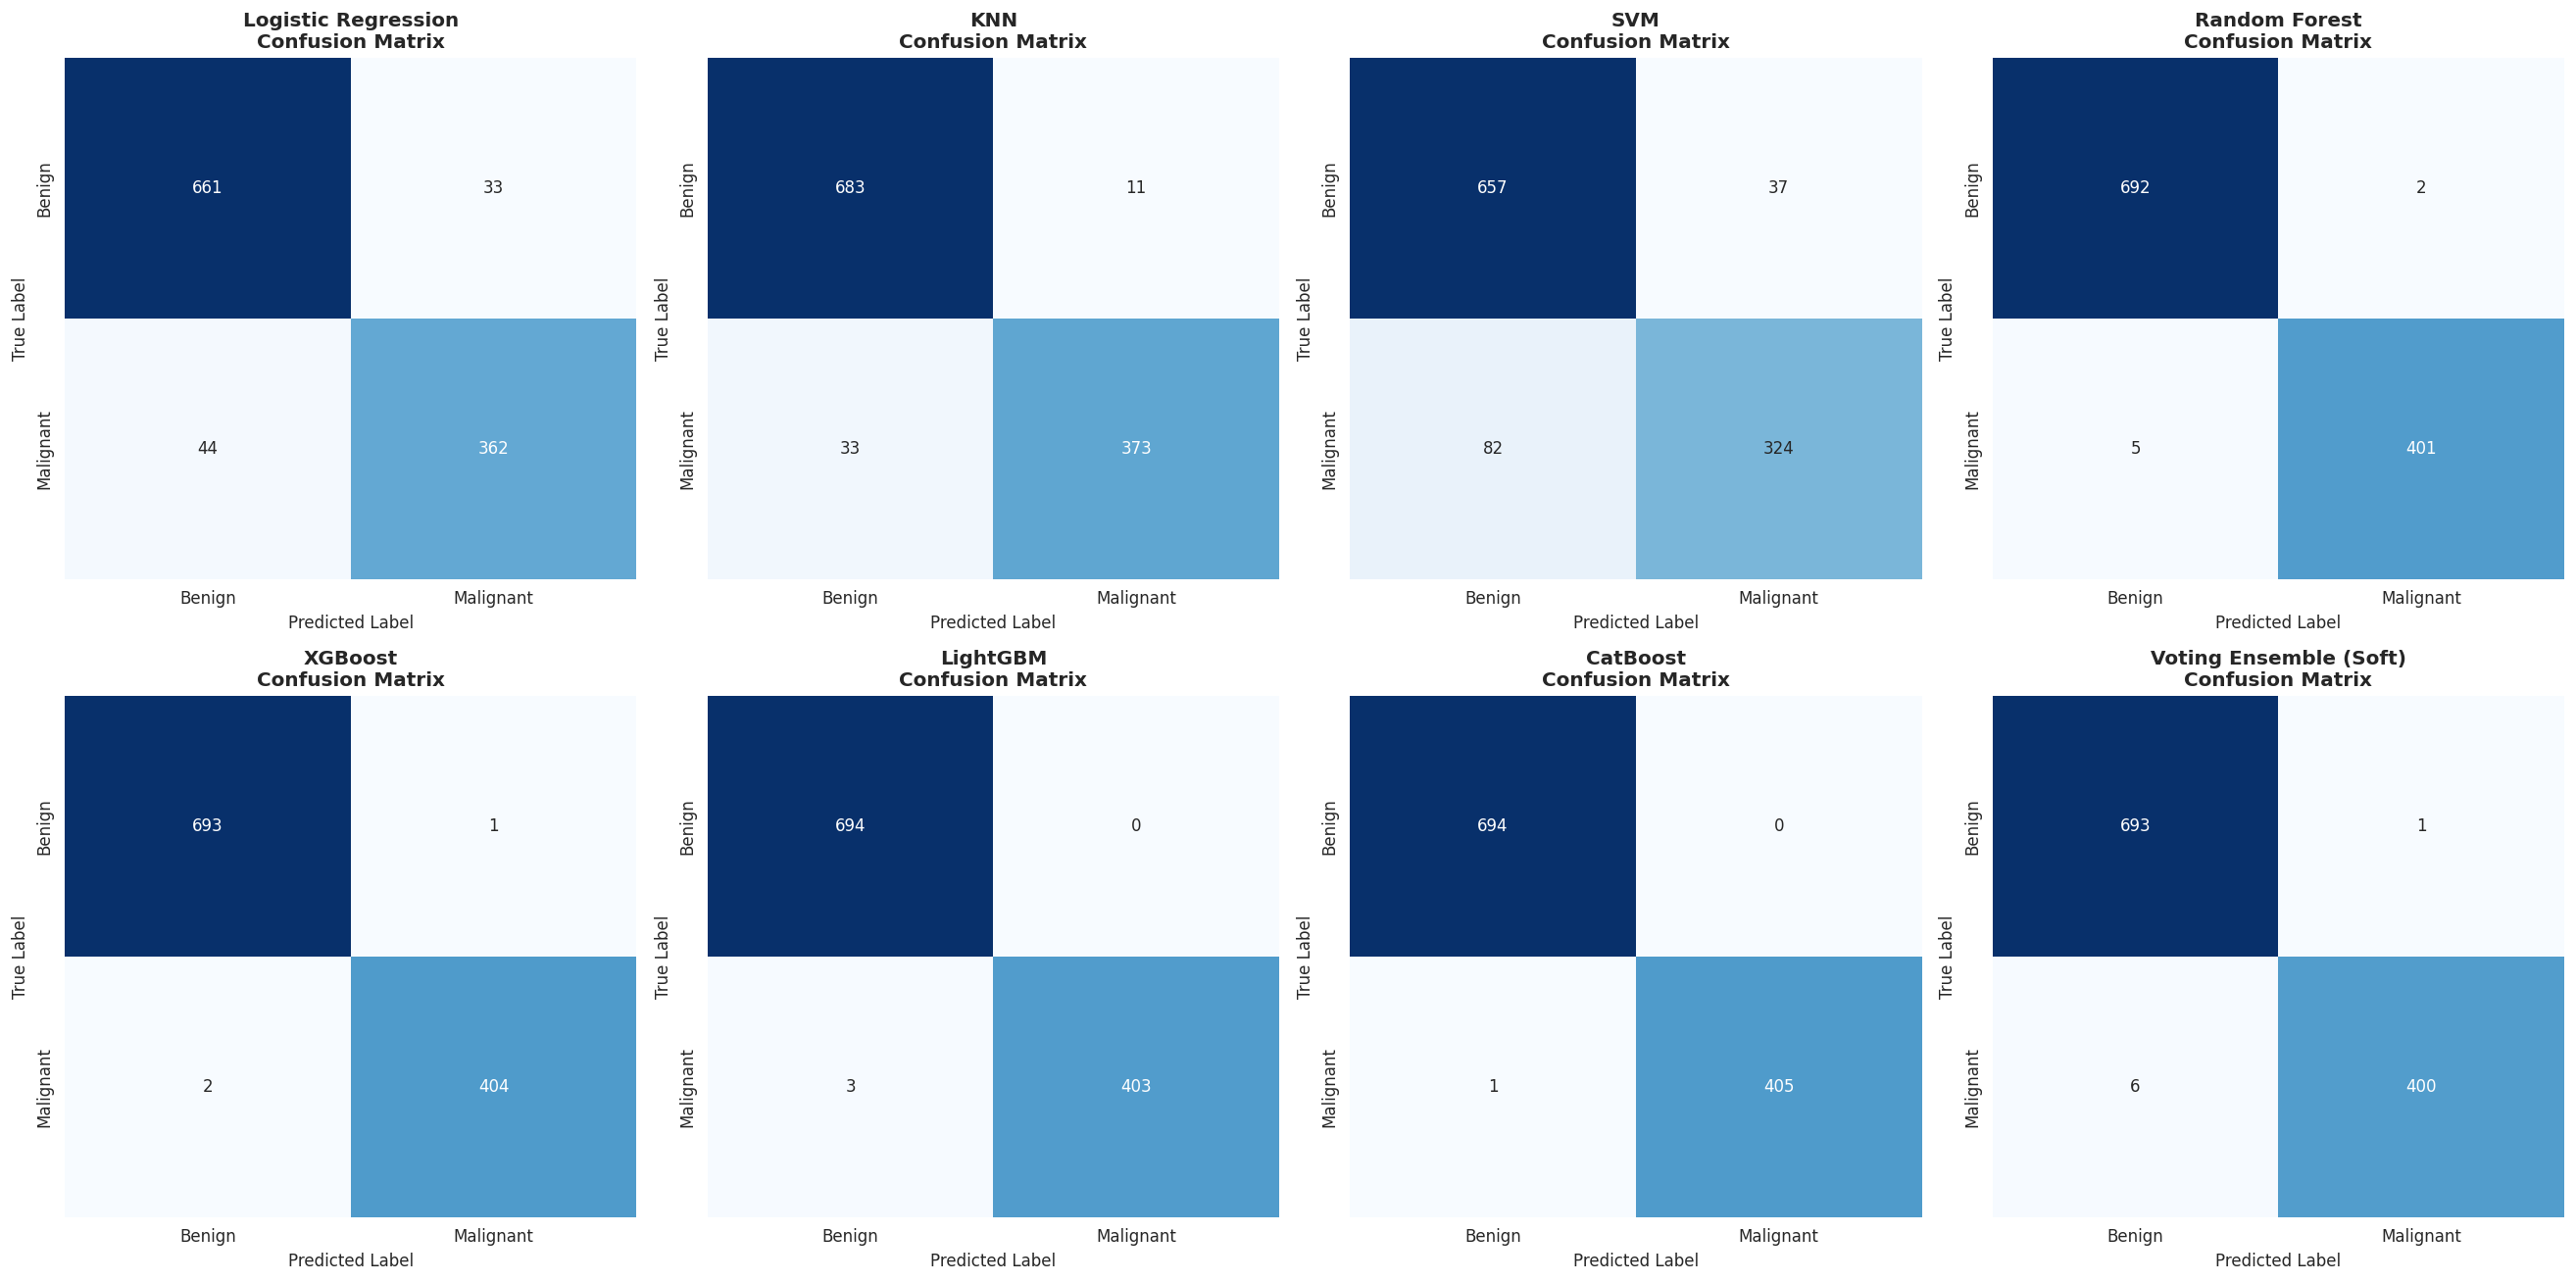

In [10]:
# ====================== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ======================
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES")
print("="*80)

# List of all models including Voting Ensemble
all_models = list(models.items()) + [("Voting Ensemble (Soft)", voting_clf)]

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.ravel()

for i, (name, model) in enumerate(all_models):
    y_pred = model.predict(X_test)

    # Classification Report
    print(f"\n🔹 {name}")
    print("-" * 60)
    print(classification_report(y_test, y_pred,
                                target_names=['Benign (B)', 'Malignant (M)'],
                                digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()

plt.show()

In [11]:
# Best Model Detailed Report
best = results_df.iloc[0]
print(f"\n🏆 Best Model: {best['Model']} (Accuracy = {best['Accuracy']:.4f})")
if best['Model'] == "Voting Ensemble (Soft)":
    print(classification_report(y_test, y_pred_vot))
else:
    print(classification_report(y_test, models[best['Model']].predict(X_test)))


🏆 Best Model: CatBoost (Accuracy = 0.9991)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       694
           1       1.00      1.00      1.00       406

    accuracy                           1.00      1100
   macro avg       1.00      1.00      1.00      1100
weighted avg       1.00      1.00      1.00      1100



In [12]:
# After training all models and showing main results_df

best_model_name = results_df.iloc[0]['Model']
print(f"Best Model: {best_model_name}")



Best Model: CatBoost


In [35]:
# ==============================
# Cross Validation for Best Model (CatBoost)
# ==============================

from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

# Define Stratified K-Fold
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Best Model
best_model = CatBoostClassifier(
    iterations=400,
    random_state=42,
    verbose=0
)

# Multiple evaluation metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1
)

print("="*60)
print("10-Fold Stratified Cross Validation Results")
print("="*60)

for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    print(f"{metric.upper():12s}: {scores.mean():.4f} ± {scores.std():.4f}")

print("="*60)

10-Fold Stratified Cross Validation Results
ACCURACY    : 0.9991 ± 0.0012
PRECISION   : 0.9990 ± 0.0029
RECALL      : 0.9985 ± 0.0023
F1          : 0.9988 ± 0.0016
ROC_AUC     : 1.0000 ± 0.0000


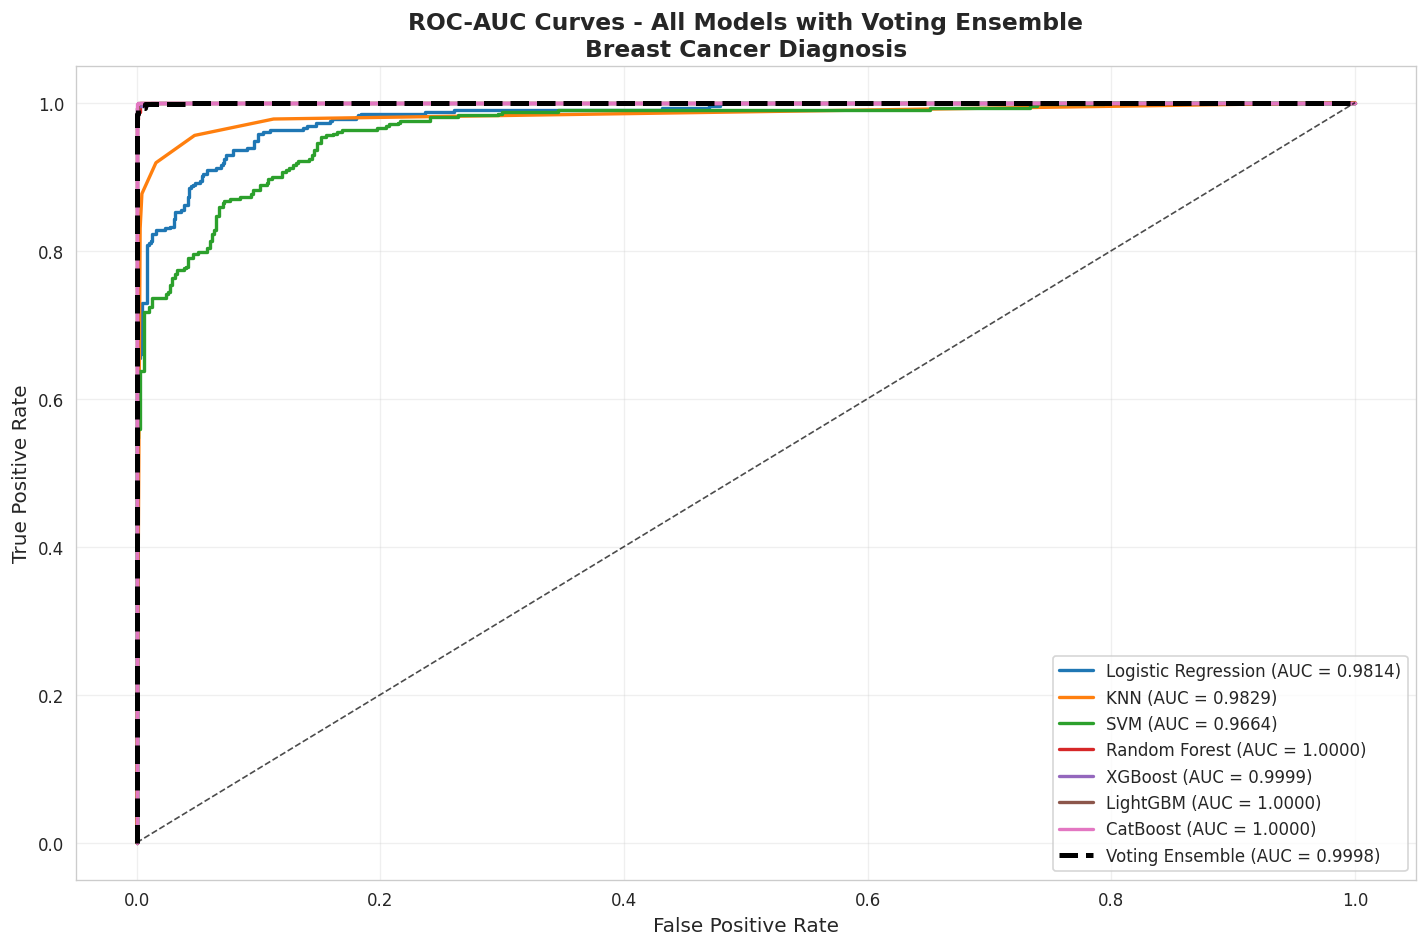

In [14]:
# ====================== COMBINED ROC-AUC CURVE ======================
from sklearn.metrics import roc_curve

plt.figure(figsize=(12, 8))

# Plot ROC for all individual models + Ensemble
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

# Voting Ensemble
y_prob_vot = voting_clf.predict_proba(X_test)[:, 1]
fpr_vot, tpr_vot, _ = roc_curve(y_test, y_prob_vot)
auc_vot = roc_auc_score(y_test, y_prob_vot)
plt.plot(fpr_vot, tpr_vot, label=f'Voting Ensemble (AUC = {auc_vot:.4f})',
         linewidth=3, linestyle='--', color='black')

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.7)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curves - All Models with Voting Ensemble\nBreast Cancer Diagnosis',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


plt.show()

Generating Precision-Recall Curves...



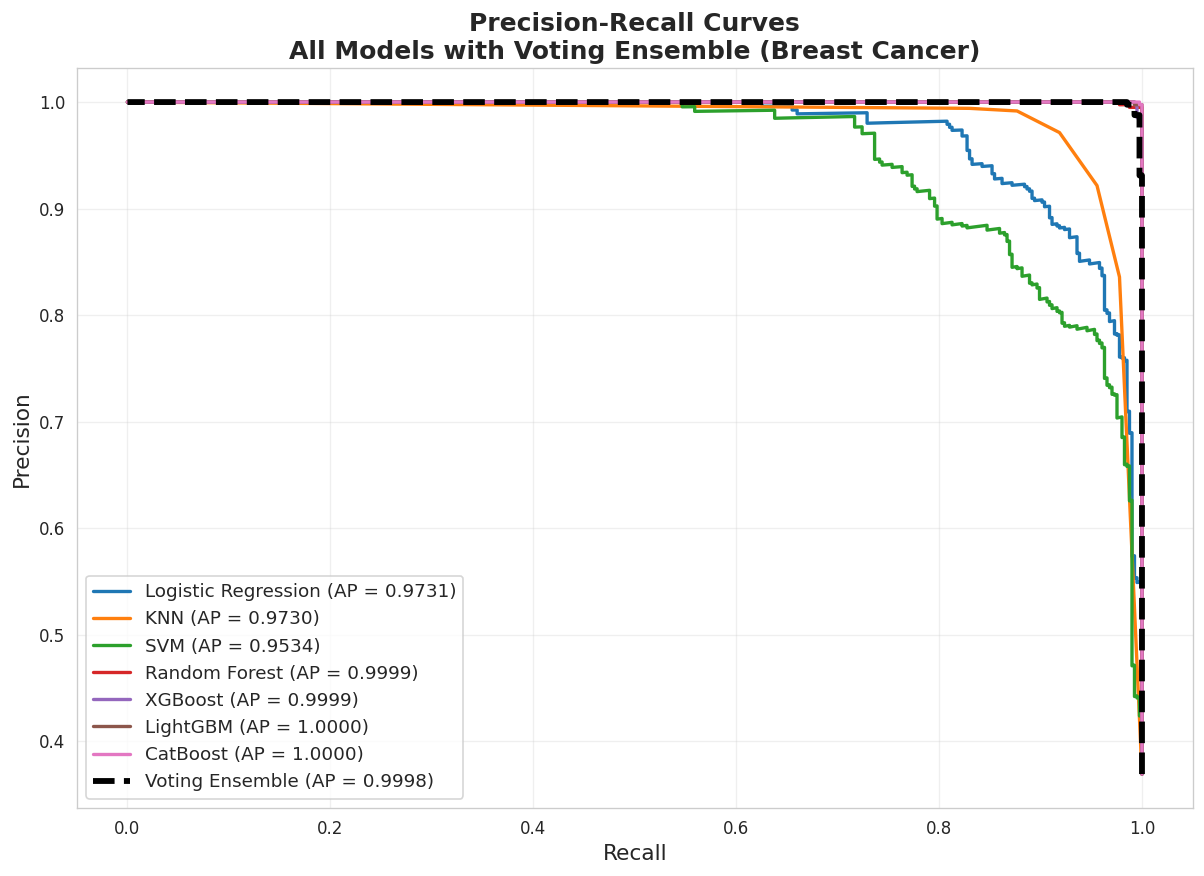

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== STEP 1: PRECISION-RECALL CURVES ======================
plt.figure(figsize=(12, 8))

print("Generating Precision-Recall Curves...\n")

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.4f})', linewidth=2)

# Voting Ensemble
y_prob_vot = voting_clf.predict_proba(X_test)[:, 1]
precision_vot, recall_vot, _ = precision_recall_curve(y_test, y_prob_vot)
ap_vot = average_precision_score(y_test, y_prob_vot)
plt.plot(recall_vot, precision_vot, label=f'Voting Ensemble (AP = {ap_vot:.4f})',
         linewidth=3.5, linestyle='--', color='black')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curves\nAll Models with Voting Ensemble (Breast Cancer)',
          fontsize=15, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()

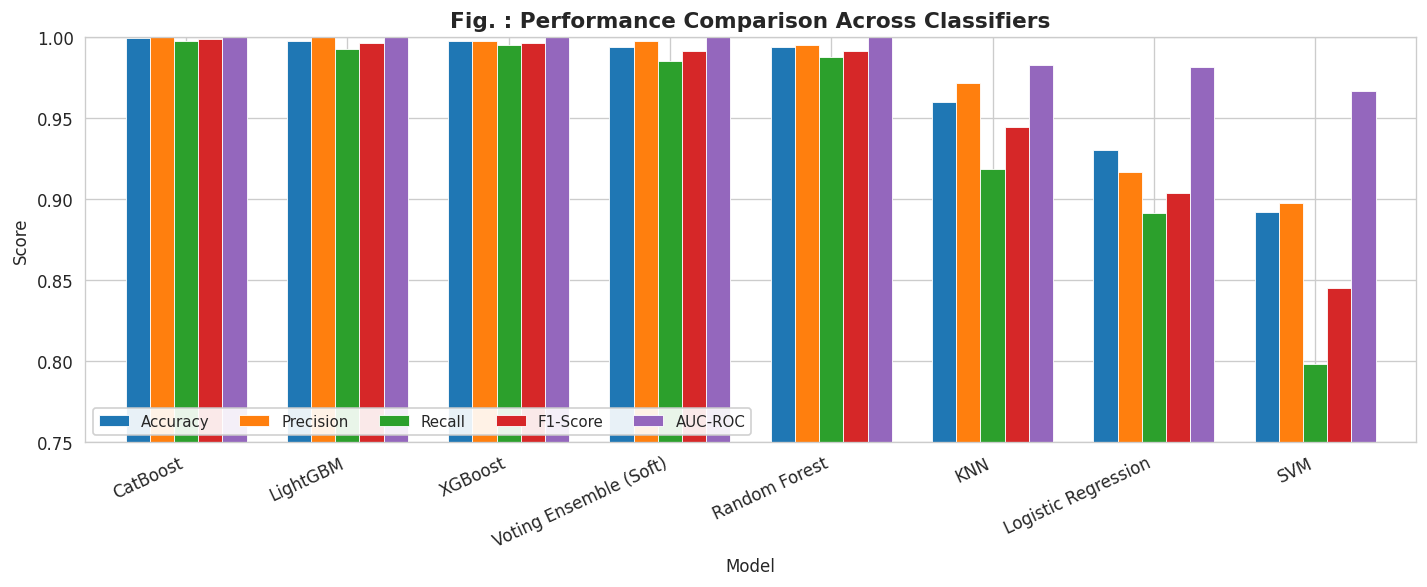

In [45]:
# ─── Fig. 5: Metric Comparison Bar Chart ───
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(0.75, 1.00)
ax.set_ylabel("Score")
ax.set_title("Fig. : Performance Comparison Across Classifiers", fontweight="bold", fontsize=13)
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()

plt.show()

In [36]:
# ==============================
# Gain-Based Feature Importance (CatBoost)
# ==============================

from catboost import CatBoostClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Train the best model
best_model = CatBoostClassifier(
    iterations=400,
    random_state=42,
    verbose=0
)

best_model.fit(X_train, y_train)

# Gain-based feature importance
importance = best_model.get_feature_importance(type='FeatureImportance')

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

print(importance_df)

                         Feature  Importance
0     radius_texture_interaction   16.736602
1                smoothness_mean   15.735071
2                   texture_mean   13.798656
3               compactness_mean    9.163776
4            concave points_mean    7.938142
5                    radius_mean    5.563837
6              border_complexity    5.498749
7          malignancy_risk_score    5.078291
8                      area_mean    4.573189
9   radius_concavity_interaction    3.651089
10             concavity_density    3.259783
11                perimeter_mean    2.993826
12          tumor_aggressiveness    2.201422
13            shape_irregularity    1.907707
14                concavity_mean    1.899860


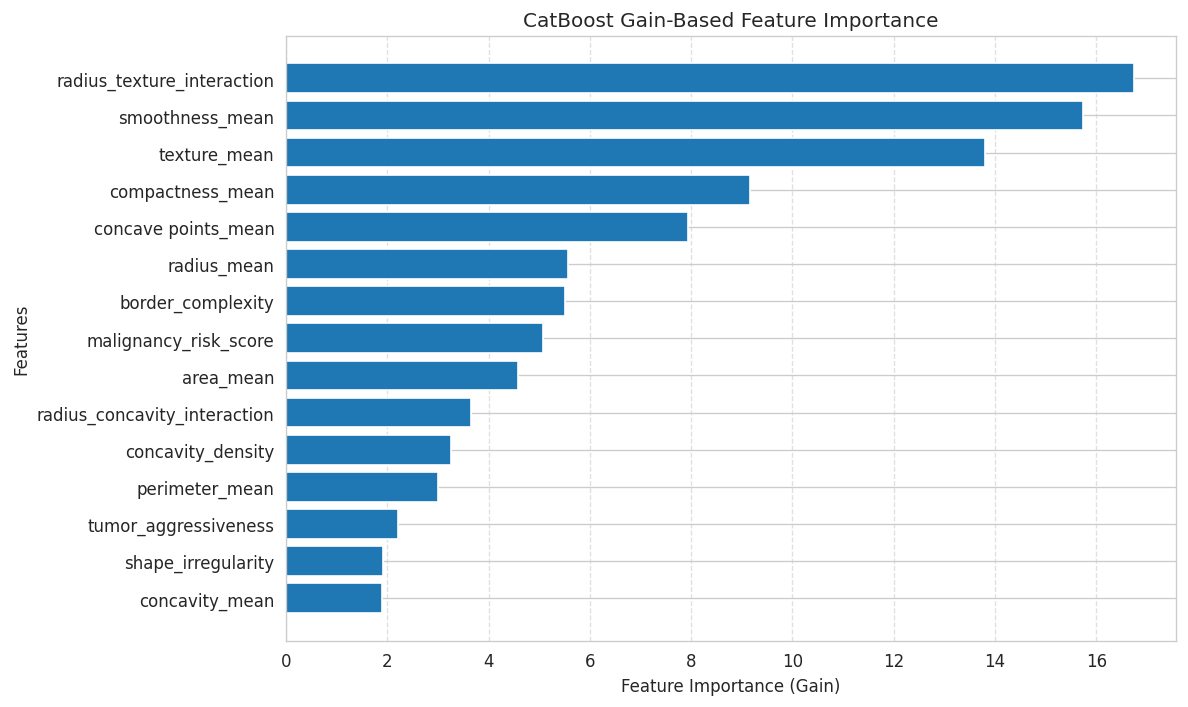

In [37]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Features')
plt.title('CatBoost Gain-Based Feature Importance')

plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [38]:
!pip install -q shap

In [39]:
import shap
import matplotlib.pyplot as plt
import numpy as np

In [40]:
from catboost import CatBoostClassifier

best_model = CatBoostClassifier(
    iterations=400,
    random_state=42,
    verbose=0
)

best_model.fit(X_train, y_train)

CatBoostClassifier(iterations=400, random_state=42, verbose=0)

In [41]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

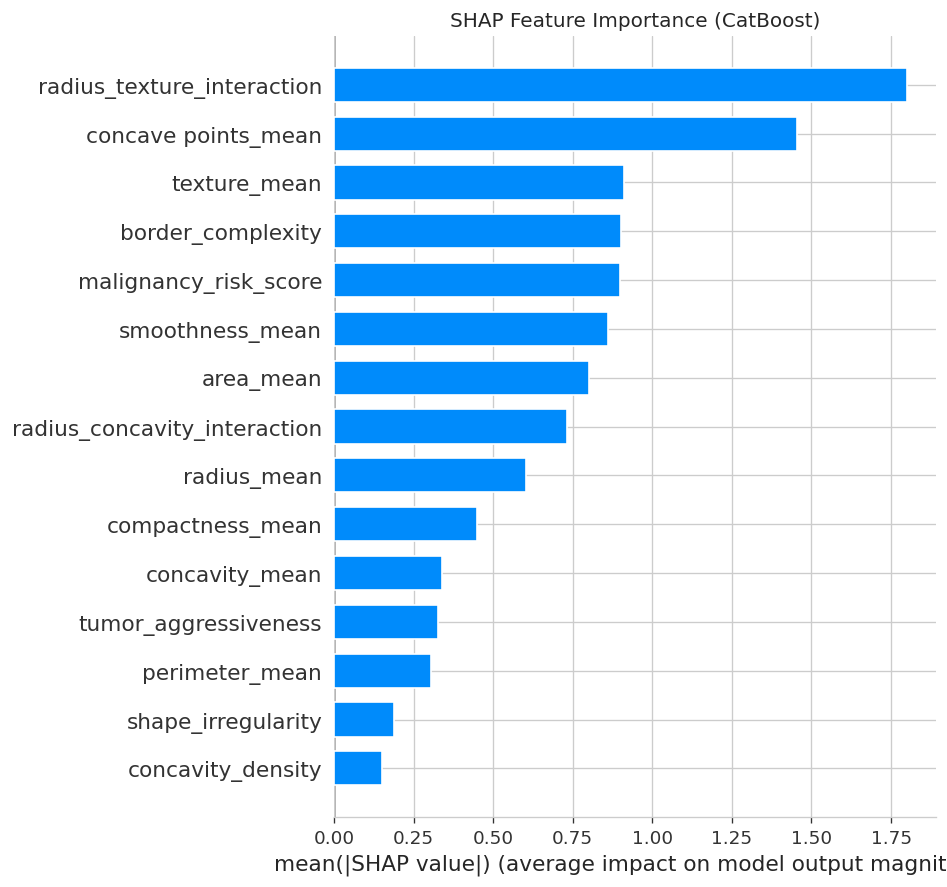

In [42]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()